## 1. Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

In [2]:
df_original = pd.read_csv("titanic_train.csv")
df_original = pd.read_csv("titanic_test.csv")
df = df_original.copy()

In [3]:
df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


## 2. Data Quality Assessment
- Converted categorical columns (Sex, Embarked) to appropriate formats.
- Removed irrelevant columns (Name, Ticket, Cabin, PassengerId).

In [4]:
df.dtypes

PassengerId      int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [5]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

In [6]:
df.dtypes

PassengerId      int64
Pclass           int64
Name            object
Sex              int64
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [7]:
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

In [8]:
df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked_Q,Embarked_S
0,892,3,"Kelly, Mr. James",0,34.5,0,0,330911,7.8292,NaN,True,False
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",1,47.0,1,0,363272,7.0000,NaN,False,True
2,894,2,"Myles, Mr. Thomas Francis",0,62.0,0,0,240276,9.6875,NaN,True,False
3,895,3,"Wirz, Mr. Albert",0,27.0,0,0,315154,8.6625,NaN,False,True
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",1,22.0,1,1,3101298,12.2875,NaN,False,True


In [9]:
df.dtypes

PassengerId      int64
Pclass           int64
Name            object
Sex              int64
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked_Q        bool
Embarked_S        bool
dtype: object

In [10]:
df = df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)

In [11]:
df.dtypes

Pclass          int64
Sex             int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Embarked_Q       bool
Embarked_S       bool
dtype: object

## 3. Handling Missing Values
- Identified missing values using df.isna().sum().

- Filled missing values in Age using median imputation.

- Dropped rows with missing Fare values due to their small number.

In [12]:
df.isna()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
413,False,False,True,False,False,False,False,False
414,False,False,False,False,False,False,False,False
415,False,False,False,False,False,False,False,False
416,False,False,True,False,False,False,False,False


In [13]:
df.isna().sum()

Pclass         0
Sex            0
Age           86
SibSp          0
Parch          0
Fare           1
Embarked_Q     0
Embarked_S     0
dtype: int64

In [25]:
# Handle missing values in the 'Age' column using median imputation
# Median is used because it is robust to outliers and suitable for numerical data
df['Age'] = df['Age'].fillna(df['Age'].median())

# Remove rows with missing values in the 'Fare' column
# This is acceptable since only a small number of records are affected
df = df.dropna(subset=['Fare'])

In [26]:
# compare shapes
print('df before drop: ', df_original.shape)
print('df after drop: ', df.shape)

# check missing
df.isna().sum()

df before drop:  (418, 11)
df after drop:  (417, 8)


Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked_Q    0
Embarked_S    0
dtype: int64

## 4. Handling Outliers
- Detected outliers using boxplots in the Age, Fare feature.
- Applied the percentile capping method.
- Reduced the impact of outliers while maintaining the overall distribution.

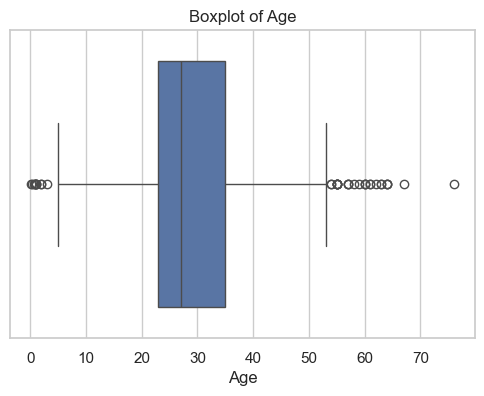

In [27]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Age'])

plt.title('Boxplot of Age')
plt.show()

In [37]:
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Age'] < lower) | (df['Age'] > upper)]
outliers.head(15)

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
2,2,0,62.0,0,0,9.6875,True,False
13,2,0,63.0,1,0,26.0000,False,True
20,1,0,55.0,1,0,59.4000,False,False
48,1,1,60.0,0,0,76.2917,False,False
69,1,1,60.0,1,4,263.0000,False,True
77,1,1,55.0,2,0,25.7000,False,True
81,1,0,67.0,1,0,221.7792,False,True
89,2,0,2.0,1,1,23.0000,False,True
96,1,1,76.0,1,0,78.8500,False,True
114,1,1,63.0,1,0,221.7792,False,True


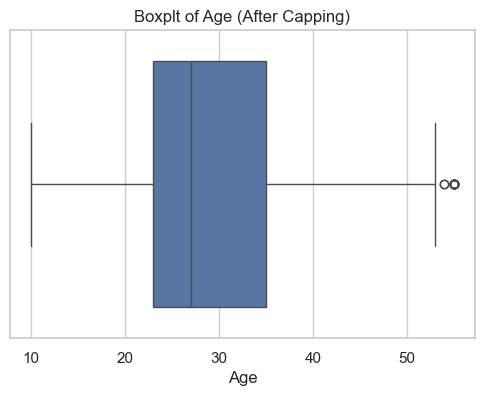

In [58]:
lower_cap = df['Age'].quantile(0.05) 
upper_cap = df['Age'].quantile(0.95) 

df_capped = df.copy()
df_capped['Age'] = df_capped['Age'].clip(lower_cap, upper_cap)

plt.figure(figsize=(6,4))
sns.boxplot(x=df_capped['Age'])

plt.title('Boxplt of Age (After Capping)')
plt.show()

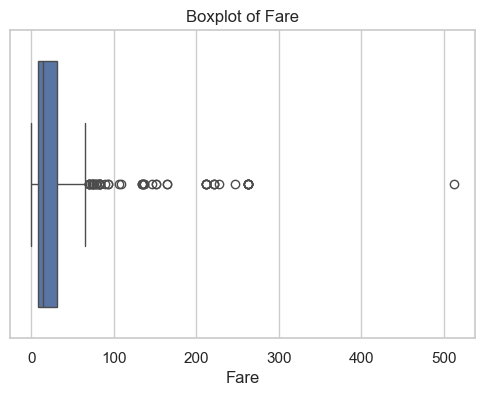

In [28]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Fare'])

plt.title('Boxplot of Fare')
plt.show()

In [36]:
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Fare'] < lower) | (df['Fare'] > upper)]
outliers.head(15)

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
12,1,1,23.0,1,0,82.2667,False,True
24,1,1,48.0,1,3,262.3750,False,False
48,1,1,60.0,0,0,76.2917,False,False
53,1,1,28.0,3,2,263.0000,False,True
59,1,1,36.0,0,0,262.3750,False,False
64,1,0,13.0,2,2,262.3750,False,False
69,1,1,60.0,1,4,263.0000,False,True
74,1,1,35.0,0,0,211.5000,False,False
75,1,0,32.5,0,0,211.5000,False,False
81,1,0,67.0,1,0,221.7792,False,True


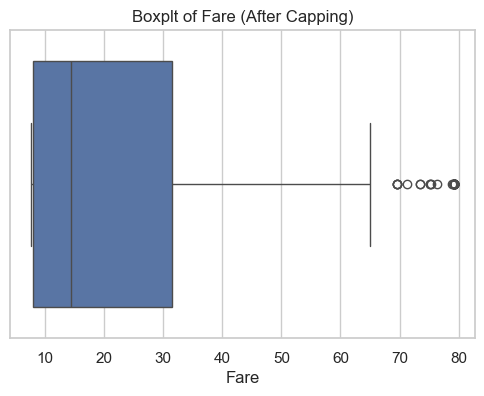

In [57]:
lower_cap = df['Fare'].quantile(0.10) 
upper_cap = df['Fare'].quantile(0.90) 

df_capped = df.copy()
df_capped['Fare'] = df_capped['Fare'].clip(lower_cap, upper_cap)

plt.figure(figsize=(6,4))
sns.boxplot(x=df_capped['Fare'])

plt.title('Boxplt of Fare (After Capping)')
plt.show()

**NOTE: Complete removal of outliers is not always necessary. reducing their influence is often sufficient for improving model performance**

## 5. Data Transformation – Normalization
- Applied normalization to numerical features (Age and Fare).
- Used Min-Max scaling to rescale values between 0 and 1.
- Used Z-score standardization to center data around mean 0 and standard deviation 1.

### 1. Min-Max Normalization

In [68]:
from sklearn.preprocessing import MinMaxScaler

df_minmax = df[['Age', 'Fare']].copy()
# scaler
scaler = MinMaxScaler()
# apply
df_minmax[['Age', 'Fare']] = scaler.fit_transform(df_minmax)

df_minmax.head()

,Age,Fare
0,0.452723,0.015282
1,0.617566,0.013663
2,0.815377,0.018909
3,0.353818,0.016908
4,0.287881,0.023984


### 2. Z-Score Normalization

In [69]:
from sklearn.preprocessing import StandardScaler

df_zscore = df[['Age', 'Fare']].copy()
# scaler
scaler = StandardScaler()
# apply
df_zscore[['Age', 'Fare']] = scaler.fit_transform(df_zscore)

df_zscore.head()

,Age,Fare
0,0.394417,-0.497811
1,1.385449,-0.512660
2,2.574688,-0.464532
3,-0.200203,-0.482888
4,-0.596616,-0.417971


## 6. Data Reduction
- Evaluated correlation between numerical features (Age and Fare).
- Found weak correlation between features.
- Decided not to apply PCA to avoid unnecessary information loss.

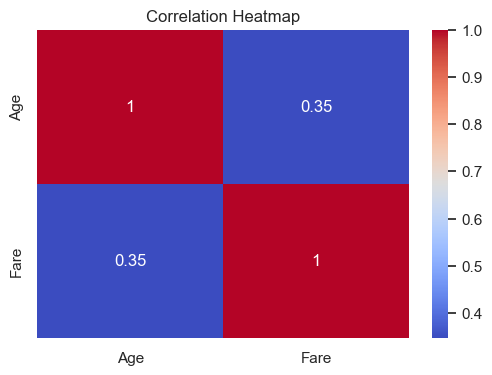

In [72]:
plt.figure(figsize=(6,4))
sns.heatmap(df_remove[['Age','Fare']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

**NOTE: The correlation between numerical features (Age and Fare) was found to be weak (close to 0). Therefore, PCA was not applied, as the features do not contain redundant information.**